# Exercise 1: Generating random numbers in a range

Using numpy.random (or whatever you like), generate:

*	An integer random number in a range [0,5] (using random.integers)
*	100 float random numbers in a range [0,5] (using random.uniform)
*	A 3x3 matrix of floats random number in a range [0,2]

Try using seed and without seed to see the difference.

In [25]:
import numpy as np

def random_integer(start, end, seed = None):
    np.random.seed(seed)
    return np.random.random_integers(start, end)

def random_floats(start,end, seed = None):
    np.random.seed(seed)
    return np.random.uniform(start,end, 100)

def random_matrix(start, end, rows, columns, seed = None):
    np.random.seed(seed)
    return np.random.uniform(start, end, (rows, columns))

print(random_integer(0,5))
print(random_floats(0,5))
print(random_matrix(0,2,3,3))


2
[3.08985359 1.75771673 0.02541101 2.81339973 1.54325748 2.32305086
 4.50841474 2.54368698 4.19460808 1.53988206 1.82639684 0.13066813
 0.11474909 2.96733156 2.19348166 2.64052055 4.79313994 2.25061081
 4.97796462 1.17742985 0.4240169  4.96878009 1.98461727 0.63894268
 3.02880713 4.25414455 0.16972503 3.15267419 4.08270885 4.19537307
 4.19286156 2.62262039 2.05588786 0.94592484 0.12427582 1.89724893
 3.06481449 4.44781158 3.52542184 2.84531135 0.21412471 4.09838152
 3.2680165  2.12108235 4.47461646 0.86611613 3.64829512 4.68176224
 4.63653281 2.01863927 1.78060526 3.07623777 1.5702558  4.68067706
 3.93880146 3.83134017 0.91996489 1.28403832 0.23532288 0.24418734
 0.70557557 4.72651315 4.15298823 4.62072315 3.91965755 1.12626665
 4.63407692 4.40468533 4.71358834 1.05733157 4.45132422 4.47439297
 1.45402078 3.29687487 2.43555138 2.62395819 1.20980068 2.76119295
 1.04790308 0.39514083 0.39103161 4.05130611 2.70063595 0.67341465
 3.45262648 1.75882726 0.78539212 0.50479047 3.13114119 3.37

C:\Users\Szymon\AppData\Local\Temp\ipykernel_10012\1358343476.py:5: DeprecationWarning: This function is deprecated. Please call randint(0, 5 + 1) instead
  return np.random.random_integers(start, end)


### Exercise 1 Discussion

In this exercise I used `np.random.random_integers` to generate an integer value. Although newer NumPy versions recommend using `np.random.randint` or the `Generator.integers()` method, the function used here still produces the required result: a random integer drawn uniformly from the specified range.

I also set a random seed using `np.random.seed()`. The seed initializes the random number generator and ensures that the same sequence of random numbers is produced each time the code is run. This makes the results reproducible.

# Exercise 2: Estimating $\pi$ value using the Monte Carlo method

$pi = 4*\dfrac{S_{\text{quarter circle}}}{S_{\text{square}}} \approx 4*\dfrac{\text{points in circle}}{\text{total points in square}}$

Step:
+	Generate a point (x,y) using 2 random numbers in a range [0,1]
+	Check if the point is inside the circle using the condition $x^2+y^2 <= 1 $
+	Repeat this procedure for many points and compute the ratio.
+	Verify the result by comparing |result - $\pi$|


In [2]:
from numpy import pi

def calculate_pi(points_number):

    coordinates = np.random.uniform(0,1, (points_number,2))
    inside_circle = 0

    for i in range(coordinates.shape[0]):
        if coordinates[i][0] ** 2 + coordinates[i][1] ** 2 <= 1:
            inside_circle += 1

    estimated_pi = 4 * inside_circle / coordinates.shape[0]

    error = abs(estimated_pi - pi)

    print(f"Based on {points_number} generated points, the estimated value of pi is {estimated_pi:}, which gives an error of {error:.6f} compared to the true value of pi.")

calculate_pi(100)   

Based on 100 generated points, the estimated value of pi is 3.16, which gives an error of 0.018407 compared to the true value of pi.


### Exercise 2 Discussion

The Monte Carlo method estimates π by sampling random points in the unit square. 
The probability that a point falls inside the quarter circle equals the ratio 
between the circle area and the square area, which leads to the estimator 
π ≈ 4 * (points_inside / total_points).

# Exercise 3: Monte Carlo Integration

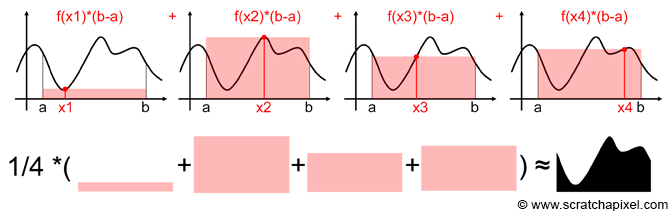

Integration:
$$I = \int_{a}^{b} y(x) dx$$
Monte Carlo Uniform distribution to estimate the integral:
$$\bar{I} = \dfrac{1}{N} \sum_{i=0}^{N-1} I(x_i)= \dfrac{1}{N} \sum_{i=0}^{N-1}(b-a) y(x_i).$$
where $I(x_i) = (b-a)y(x_i)$.

**Standard deviation** of I:
$$ \sigma_{I} =  \sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2}$$
**Standard error** of the estimate:
$$ \sigma_{\bar{I}} =  \dfrac{\sigma_I}{\sqrt{N}}$$
 <!-- $$ \Rightarrow \sigma_{\bar{I}} =  \dfrac{1}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2} =  \dfrac{(b-a)}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (y(x_i) - \overline{y})^2}$$ -->

+	Define a function named **MC_1dim(lower_bound,upper_bound,func,n_points)** to compute the integral of an arbitrary one-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and  the standard error  $\sigma_{\bar{I}}$ , i.e $<I> = \bar{I} \pm \sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi} sin(x) dx$ 

+	Verify the result by calculating the absolute error: $|\bar{I} - 2|$
+	Analyze the convergence: Change the number of points and plot the absolute error and the Standard error (std) as a function of the number of points using log-log scale. Discussion: How do these errors behave as the number of points increases?
+	Compare the convergence of the Monte Carlo method and the trapezoid (use np.trapezoid()) method by plotting the absolute error of both approaches using log-log scale. Which method converges faster for this one-dimensional integral? 
+	How do these method errors scale as O($1/N^{\alpha}$). Compute the slope to find the $\alpha$ value for each method by choosing any 2 pairs $(x_1,y_1), (x_2,y_2)$ from the log-log plot:

	$\alpha = -\dfrac{\log(y_2)-\log(y_1)}{\log(x_2)-\log(x_1)}$

Hint: The expected values are $\alpha_{MC} = 0.5$ and $\alpha_{trapezoid} = 2$.

Estimated integral value for N=10000: 1.999094
Standard error: 0.009611
Absolute error |I_bar - 2|: 0.000906



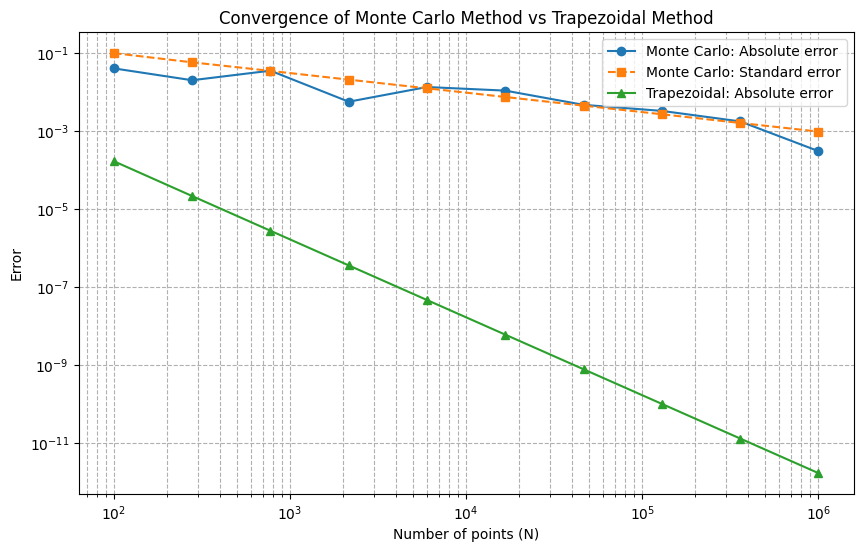

Calculated slope (alpha) for Monte Carlo: 0.4883 (Expected ~0.5)
Calculated slope (alpha) for Trapezoidal: 2.0004 (Expected ~2.0)


In [26]:
import matplotlib.pyplot as plt

#Monte Carlo function for 1 dimension
def MC_1dim(lower_bound, upper_bound, func, n_points):

    x = np.random.uniform(lower_bound, upper_bound, n_points)
    y = func(x)

    # I(x_i) = (b - a) * y(x_i)
    V = upper_bound - lower_bound
    I_x = V * y

    I_bar = np.mean(I_x)

    # Standard deviation and standard error, ddof=1 to divide by N-1 (according to the formula)
    sigma_I = np.std(I_x, ddof=1) 
    sigma_I_bar = sigma_I / np.sqrt(n_points)
    
    return I_bar, sigma_I_bar

# The integral of sin(x) over the interval [0, pi]

lower = 0
upper = np.pi
func = np.sin
true_value = 2.0

n_test = 10000
I_est, std_err = MC_1dim(lower, upper, func, n_test)
abs_err = abs(I_est - true_value)

print(f"Estimated integral value for N={n_test}: {I_est:.6f}")
print(f"Standard error: {std_err:.6f}")
print(f"Absolute error |I_bar - 2|: {abs_err:.6f}\n")

#Convergence analysis and comparison with the trapezoidal method
n_points_list = np.logspace(2, 6, 10, dtype=int) # From 100 to 1,000,000 points

mc_abs_errors = []
mc_std_errors = []
trapz_abs_errors = []

for N in n_points_list:
    # Monte Carlo
    I_bar, sigma_I_bar = MC_1dim(lower, upper, func, N)
    mc_abs_errors.append(abs(I_bar - true_value))
    mc_std_errors.append(sigma_I_bar)

    # Trapezoidal method
    x_trapz = np.linspace(lower, upper, N)
    y_trapz = func(x_trapz)
    I_trapz = np.trapz(y_trapz, x_trapz) 
    trapz_abs_errors.append(abs(I_trapz - true_value))

plt.figure(figsize=(10, 6))
plt.loglog(n_points_list, mc_abs_errors, 'o-', label='Monte Carlo: Absolute error')
plt.loglog(n_points_list, mc_std_errors, 's--', label='Monte Carlo: Standard error')
plt.loglog(n_points_list, trapz_abs_errors, '^-', label='Trapezoidal: Absolute error')

plt.xlabel('Number of points (N)')
plt.ylabel('Error')
plt.title('Convergence of Monte Carlo Method vs Trapezoidal Method')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# The slope (alpha)
idx1, idx2 = 2, -2
x1, x2 = n_points_list[idx1], n_points_list[idx2]

# Alpha for Monte Carlo
y1_mc, y2_mc = mc_abs_errors[idx1], mc_abs_errors[idx2]
alpha_mc = - (np.log(y2_mc) - np.log(y1_mc)) / (np.log(x2) - np.log(x1))

# Alpha for Trapezoidal
y1_trap, y2_trap = trapz_abs_errors[idx1], trapz_abs_errors[idx2]
alpha_trap = - (np.log(y2_trap) - np.log(y1_trap)) / (np.log(x2) - np.log(x1))

print(f"Calculated slope (alpha) for Monte Carlo: {alpha_mc:.4f} (Expected ~0.5)")
print(f"Calculated slope (alpha) for Trapezoidal: {alpha_trap:.4f} (Expected ~2.0)")

### Exercise 3 Discussion

To analyze convergence, I changed the number of sampled points and plotted:
- the absolute error,
- the standard error,

as functions of the number of points on a log-log scale.

As expected, both errors decrease as the number of points increases. However, the **absolute error of Monte Carlo is noisy**, because every estimate is based on random sampling. For this reason, the absolute error from a single run does not follow the theoretical trend perfectly.

The **standard error** shows the theoretical convergence behavior more clearly. In Monte Carlo integration, the expected scaling is

$$
\text{error} \sim \frac{1}{N^{1/2}}
$$

so on a log-log plot the expected slope corresponds to

$$
\alpha_{MC} \approx 0.5
$$

#### Comparison with the trapezoidal method

I also compared the Monte Carlo method with the trapezoidal method by plotting the absolute errors of both methods on a log-log scale.

In the notebook I used `np.trapz()` instead of `np.trapezoid()` because `np.trapezoid()` is not available in the NumPy version used here. The `np.trapz()` function performs the same trapezoidal approximation.

For this smooth one-dimensional function, the trapezoidal method converges much faster than Monte Carlo. Its error behaves approximately like

$$
\text{error} \sim \frac{1}{N^2}
$$

which corresponds to the expected slope

$$
\alpha_{trapezoid} \approx 2
$$

### Interpretation of the slopes

The slope $\alpha$ is computed from two points $(x_1,y_1)$ and $(x_2,y_2)$ on the log-log plot using

$$
\alpha = - \frac{\log(y_2)-\log(y_1)}{\log(x_2)-\log(x_1)}
$$

The expected values are

- $\alpha_{MC} \approx 0.5$
- $\alpha_{trapezoid} \approx 2$

In practice:
- the trapezoidal slope is usually very close to 2,
- the Monte Carlo slope estimated from the **standard error** is usually close to 0.5,
- the slope estimated from the **absolute error of a single run** may differ because of random fluctuations.

#### Final conclusion

The results show that the Monte Carlo method converges more slowly than the trapezoidal method for the smooth one-dimensional integral

$$
\int_0^\pi \sin(x)\,dx
$$

The trapezoidal rule is more efficient in this case because its error decreases approximately as $1/N^2$, while the Monte Carlo error decreases only as $1/\sqrt{N}$.

However, Monte Carlo integration remains useful because its convergence rate is much less sensitive to the dimensionality of the problem, which makes it suitable for higher-dimensional integrals.

# Exercise 4: Higher dimension integration
In n-dimension

Simple Integration:
$$I = \int_{a}^{b}\int_{a}^{b} ...\int_{a}^{b}dx_1dx_2...dx_n f(x_1,x_2,...,x_n)$$
The estimation value:
$$\bar{I} = (b-a)^n \sum_{i=0}^{N-1} \dfrac{f(x_{1i},x_{2i},...,x_{ni})}{N}.$$
**Standard error** of the estimate:
 $$ \sigma_{\bar{I}} =    \dfrac{(b-a)^n}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (f(x_{1i},x_{2i},...,x_{ni}) - \overline{f})^2}$$

+	Define a function named **MC_ndim(lower,upper,func,n_dims,n_points)** to compute the integral of an arbitrary n-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and the standard error $\sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi}\int_{0}^{\pi} sin(x_1) sin(x_2) dx_1 dx_2$ 

+ Compute the above integral for $n_{dims} = 5,7,9$ and plot the absolute values $|\bar{I} - 2^n|$ for these dimension values as a function of n_points using log-log scale. Does the slope of error line change when we increase the dimension ? What is your conclusion ? 

2D Integral Result (N=10000): 3.9856
Absolute Error vs 2^2: 0.0144

Estimated alpha for n=5: 0.4515
Estimated alpha for n=7: 0.5324
Estimated alpha for n=9: 0.5021


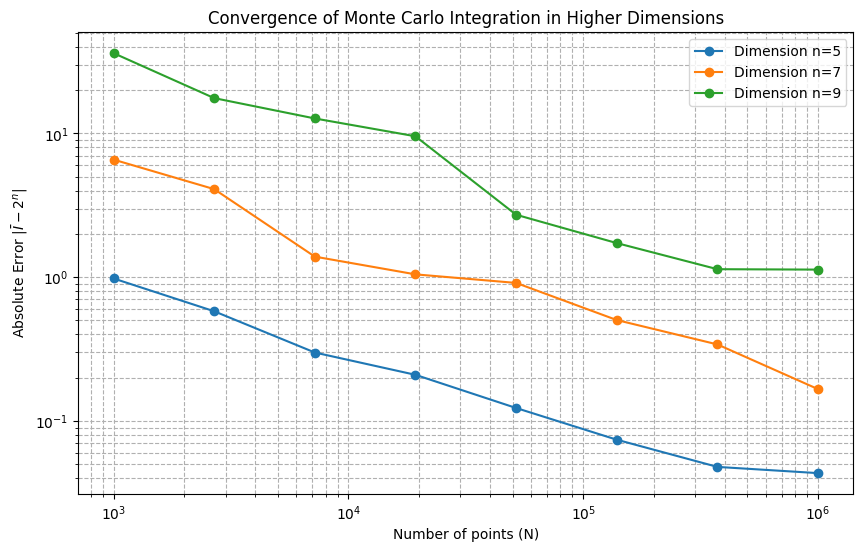

In [27]:
# Function for n-dimensional Monte Carlo integration
def MC_ndim(lower, upper, func, n_dims, n_points):

    pts = np.random.uniform(lower, upper, (n_points, n_dims))
    y = func(pts)

    V = (upper - lower)**n_dims
    I_x = V * y

    I_bar = np.mean(I_x)

    sigma_I = np.std(I_x, ddof=1)
    sigma_I_bar = sigma_I / np.sqrt(n_points)
    
    return I_bar, sigma_I_bar

# Integration function: sin(x1) * sin(x2) * ... * sin(xn)
def func_ndim(x):
    return np.prod(np.sin(x), axis=1)

I_2d, err_2d = MC_ndim(0, np.pi, func_ndim, 2, 10000)
print(f"2D Integral Result (N=10000): {I_2d:.4f}")
print(f"Absolute Error vs 2^2: {abs(I_2d - 4):.4f}\n")

# Convergence for dimensions 5, 7, and 9
dims = [5, 7, 9]
n_points_list_nd = np.logspace(3, 6, 8, dtype=int) # From 1,000 to 1,000,000 points

plt.figure(figsize=(10, 6))

for d in dims:
    errors = []
    true_val = 2**d
    
    for N in n_points_list_nd:
        run_errors = []
        
        for _ in range(10):  # Repeat to reduce Monte Carlo noise
            I_bar, _ = MC_ndim(0, np.pi, func_ndim, d, N)
            run_errors.append(abs(I_bar - true_val))
        
        errors.append(np.mean(run_errors))
        
    plt.loglog(n_points_list_nd, errors, 'o-', label=f'Dimension n={d}')
    
    # Compute slope alpha from first and last point
    x1, x2 = n_points_list_nd[0], n_points_list_nd[-1]
    y1, y2 = errors[0], errors[-1]
    alpha = -(np.log(y2) - np.log(y1)) / (np.log(x2) - np.log(x1))
    print(f"Estimated alpha for n={d}: {alpha:.4f}")

plt.xlabel('Number of points (N)')
plt.ylabel(r'Absolute Error $|\bar{I} - 2^n|$')
plt.title('Convergence of Monte Carlo Integration in Higher Dimensions')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### Exercise 4 Discussion

The error decreases as the number of points increases for all tested dimensions. As expected, higher-dimensional cases tend to have larger absolute errors for the same number of sampled points.

However, the overall convergence behavior remains similar across dimensions. This is a key property of Monte Carlo integration: its convergence rate is expected to scale approximately as

$$
\frac{1}{N^{1/2}}
$$

independently of the dimension.

The curves may still look noisy because Monte Carlo estimates are random. To reduce fluctuations, the absolute error can be averaged over several independent runs for each value of $N$.

The estimated slopes $\alpha$ for different dimensions remain roughly close to $0.5$, which indicates that increasing the dimension does not significantly change the convergence rate itself. Instead, higher dimensions mainly increase the magnitude of the error.

#### Final conclusion

The main advantage of Monte Carlo integration is that its convergence rate does not deteriorate strongly with dimension. Although the absolute error becomes larger in higher dimensions, the slope of the error line stays approximately the same.

This makes Monte Carlo methods much more suitable for high-dimensional integration than deterministic methods such as the trapezoidal rule.